In [1]:
import sys
import os
 
sys.path.append(os.path.abspath("../zoorvival"))

In [2]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split

from zoorvival.data import load_tcga_data
from zoorvival.nn.training import as_torch_dataset

%reload_ext autoreload
%autoreload 2

np.random.seed(42)
torch.manual_seed(42);

In [3]:
PROJECT = "BRCA"

VAL_SPLIT = 0.1

NUM_BINS = 32  # Number of bins for discretizing time

BATCH_SIZE = 32

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
db = load_tcga_data(PROJECT)

In [6]:
db.train.__annotations__

{'df_clinical': pandas.core.frame.DataFrame,
 'df_cnv': pandas.core.frame.DataFrame,
 'df_dnam': pandas.core.frame.DataFrame,
 'df_mirna': pandas.core.frame.DataFrame,
 'df_mrna': pandas.core.frame.DataFrame,
 'wsi_embeddings': numpy.ndarray,
 'y': numpy.ndarray}

## EDA

In [7]:
from sksurv.ensemble import RandomSurvivalForest

X_train = db.train.df_clinical
X_test = db.test.df_clinical
y_train = db.train.y
y_test = db.test.y

model = RandomSurvivalForest(n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test).item()

0.7961165048543689

In [8]:
ds_train = as_torch_dataset(db.train)
ds_test = as_torch_dataset(db.test)

train_size = int((1 - VAL_SPLIT) * len(ds_train))
val_size = len(ds_train) - train_size

ds_train, ds_val = random_split(ds_train, [train_size, val_size])

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
batch = next(iter(dl_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_types = [
    "Clinical",
    "Copy Number Variation",
    "DNA Methylation",
    "MicroRNA",
    "mRNA",
    "WSI Embeddings",
    "Event",
    "Time"
]

records = []
for k, v in zip(data_types, batch):
    v = v.to(device)
    records.append({
        "Content": k,
        "Shape": tuple(v.shape),
        "dtype": str(v.dtype),
        "Device": str(v.device)
    })

print("List of output tensors from a single batch:")
pd.DataFrame(records)

List of output tensors from a single batch:


,Content,Shape,dtype,Device
0,Clinical,"(32, 565)",torch.float32,cpu
1,Copy Number Variation,"(32, 4096)",torch.float32,cpu
2,DNA Methylation,"(32, 4096)",torch.float32,cpu
3,MicroRNA,"(32, 306)",torch.float32,cpu
4,mRNA,"(32, 4096)",torch.float32,cpu
5,WSI Embeddings,"(32, 64, 1536)",torch.float32,cpu
6,Event,"(32,)",torch.float32,cpu
7,Time,"(32,)",torch.float32,cpu


In [10]:
min_time = db.train.y["time"].min()
max_time = db.train.y["time"].max()
bin_edges = torch.linspace(min_time, max_time, NUM_BINS + 1, device=device)
print(f"Time bin edges: {bin_edges}")

Time bin edges: tensor([  0.0000,   8.8341,  17.6681,  26.5022,  35.3363,  44.1703,  53.0044,
         61.8384,  70.6725,  79.5066,  88.3406,  97.1747, 106.0088, 114.8428,
        123.6769, 132.5109, 141.3450, 150.1791, 159.0131, 167.8472, 176.6812,
        185.5153, 194.3494, 203.1834, 212.0175, 220.8516, 229.6856, 238.5197,
        247.3538, 256.1878, 265.0219, 273.8559, 282.6900])


In [11]:
def time_to_bin(t: torch.Tensor) -> torch.LongTensor:
    return torch.bucketize(t, bin_edges, right=True).clip(0, NUM_BINS - 1)

In [12]:
import torch.nn as nn
import torch.nn.functional as F


def make_mlp(in_dim, hidden=(256, 128), out_dim=64):
    layers = []
    last = in_dim
    for h in hidden:
        layers += [nn.Linear(last, h), nn.ReLU(), nn.Dropout(0.1)]
        last = h
    layers.append(nn.Linear(last, out_dim))
    return nn.Sequential(*layers)

class Modalities(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_clinical = make_mlp(155)
        self.enc_cnv      = make_mlp(4096)
        self.enc_dnam     = make_mlp(4096)
        self.enc_mirna    = make_mlp(306)
        self.enc_mrna     = make_mlp(4096)
        self.enc_wsi      = make_mlp(1536)

    def forward(self, batch):
        h = []
        h.append(self.enc_clinical(batch[0]))
        h.append(self.enc_cnv     (batch[1]))
        h.append(self.enc_dnam    (batch[2]))
        h.append(self.enc_mirna   (batch[3]))
        h.append(self.enc_mrna    (batch[4]))
        for i in range(batch[5].shape[1]):
            h.append(self.enc_wsi(batch[5][:, i, :]))
        return torch.cat(h, dim=1)          # shape [B, N × 64]


In [13]:
class LogisticHazard(nn.Module):
    def __init__(self, embedding_dim=64 * 69, hidden=(256,), num_bins=NUM_BINS):
        super().__init__()
        layers = []
        last = embedding_dim
        for h in hidden:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.backbone = nn.Sequential(*layers)
        self.out = nn.Linear(last, num_bins)

    def forward(self, phi):
        return self.out(self.backbone(phi))

In [14]:
class MultiModalDeepHit(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Modalities()
        self.head = LogisticHazard()

    def forward(self, batch):
        phi = self.enc(batch)
        return self.head(phi)

def logistic_hazard_loss(logits, events, times):
    """
    Compute the loss for the Logistic Hazard model.
    """
    # logits: [B, num_bins]
    # times: [B]
    # event: [B]
    
    # One-hot encode time
    time_bins = time_to_bin(times)
    time_bins = F.one_hot(time_bins, num_classes=NUM_BINS).float()  # [B, num_bins]
    # Compute the cross-entropy loss
    ce_loss = F.binary_cross_entropy_with_logits(logits, time_bins, reduction="none")  # [B, num_bins]
    # Mask the loss for censored events and bins after the event time
    mask = torch.arange(NUM_BINS, device=logits.device).expand(len(times), NUM_BINS) >= time_bins.sum(dim=1, keepdim=True)
    mask = mask & events.unsqueeze(1).bool()  # [B, num_bins]

    # Compute the masked loss
    masked_loss = ce_loss * mask.float()
    # Sum the loss over the bins and take the mean
    loss = masked_loss.sum(dim=1) / masked_loss.sum(dim=1).clamp(min=1e-6)  # [B]
    return loss.mean()  # Scalar

In [15]:
from torch.optim import Adam
from tqdm.notebook import tqdm


model = MultiModalDeepHit().to(device)
opt   = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def train_epoch(loader):
    model.train()
    total, n = 0.0, 0
    bar = tqdm(loader, desc="Training", leave=False)
    for batch in bar:
        for i, v in enumerate(batch):
            batch[i] = v.to(device)

        opt.zero_grad()
        logits = model(batch)
        loss = logistic_hazard_loss(logits, batch[6], batch[7])
        loss.backward()
        opt.step()

        total += loss.item()
        n += len(batch[0])
        bar.set_postfix(loss=total/n)

In [16]:
model

MultiModalDeepHit(
  (enc): Modalities(
    (enc_clinical): Sequential(
      (0): Linear(in_features=155, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=128, out_features=64, bias=True)
    )
    (enc_cnv): Sequential(
      (0): Linear(in_features=4096, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=128, out_features=64, bias=True)
    )
    (enc_dnam): Sequential(
      (0): Linear(in_features=4096, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=Fa

In [17]:
n_epochs = 32
for epoch in range(1, n_epochs + 1):
    l = train_epoch(dl_train)

Training:   0%|          | 0/19 [00:00<?, ?it/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x565 and 155x256)

In [ ]:
# Compute the logits on the entire test set
logits = []
with torch.no_grad():
    for batch in tqdm(dl_test):
        for i, v in enumerate(batch):
            batch[i] = v.to(device)
        logits.append(model(batch).cpu().numpy())
logits = np.concatenate(logits, axis=0)

  0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
from sksurv.metrics import concordance_index_censored

h = F.softmax(torch.from_numpy(logits), dim=-1).numpy()
S = (1 - h).cumprod(axis=-1)

preds = -np.sum(S, axis=-1)

concordance_index_censored(
    db.test.y["event"],
    db.test.y["time"],
    preds,
)[0].item()

0.5

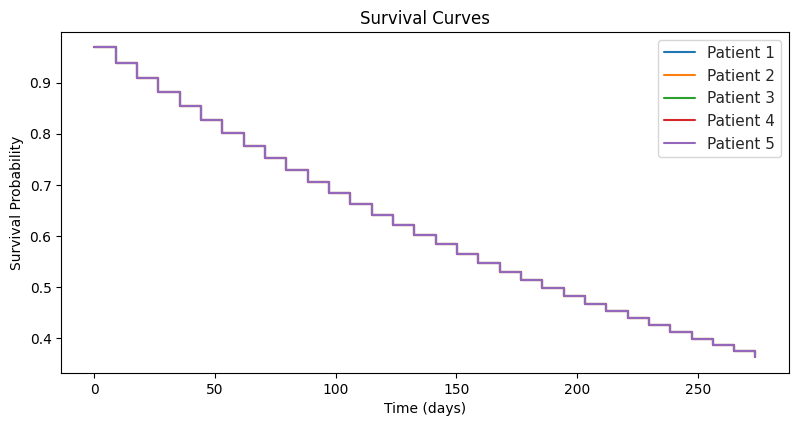

In [ ]:
# Plotting survival curves
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
fig.tight_layout()
sns.set_style("whitegrid")
sns.set_context("notebook")

for i in range(5):
    ax.plot(bin_edges[:-1].cpu().numpy(), S[i], label=f"Patient {i+1}", drawstyle="steps-post")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability")
ax.set_title("Survival Curves")
ax.legend()
plt.show()